In [3]:
import sys
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# konfigurasi logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)])

# setup direktori
current_dir = Path.cwd()
logging.info(f"working directory: {current_dir}")

# dataset
df = pd.read_csv("experiment.csv")
display(df.head())

X = df.values

2026-03-13 08:16:03,176 - INFO - working directory: /home/cation-pi/Documents/kelompokD_sk5004/pca


,x,y
0,1,2
1,2,3
2,3,5
3,4,4
4,5,6


In [5]:
mean_vec = np.mean(X, axis=0)
std_vec = np.std(X, axis=0)

X_std = (X - mean_vec) / std_vec

logging.info(f"rata-rata X_std: {np.mean(X_std):.20f}")
logging.info(f"standar deviasi X_std: {np.std(X_std):.20f}")

df_std_preview = pd.DataFrame(X_std)
display(df_std_preview.head())

2026-03-13 08:16:43,285 - INFO - rata-rata X_std: 0.00000000000000002220
2026-03-13 08:16:43,286 - INFO - standar deviasi X_std: 1.00000000000000000000


,0,1
0,-1.566699,-1.513289
1,-1.218544,-1.184313
2,-0.870388,-0.526361
3,-0.522233,-0.855337
4,-0.174078,-0.197386


In [6]:
# step 2
cov_mat = np.cov(X_std.T)
logging.info(f"dimensi covariance matrix: {cov_mat.shape}")

# step 3: Σv = λv
# Σ = cov_mat, v = eigenvector, λ = eigenvalue.
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
logging.info(f"jumlah eigenvalues: {len(eigen_vals)}")
logging.info(f"dimensi matriks eigenvectors: {eigen_vecs.shape}")
print('\nEigenvalues:')
print(eigen_vals)

2026-03-13 08:17:03,913 - INFO - dimensi covariance matrix: (2, 2)
2026-03-13 08:17:03,922 - INFO - jumlah eigenvalues: 2
2026-03-13 08:17:03,923 - INFO - dimensi matriks eigenvectors: (2, 2)

Eigenvalues:
[2.20555369 0.01666853]


In [8]:
# step 4
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

# step 5 dan 6
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

w = np.hstack((eigen_pairs[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
logging.info(f"dimensi matriks proyeksi w: {w.shape}")
print('matriks w:\n', w)

2026-03-13 08:18:04,331 - INFO - dimensi matriks proyeksi w: (2, 2)
matriks w:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


2026-03-13 08:26:53,812 - INFO - dimensi dataset sebelum pca: (10, 2)
2026-03-13 08:26:53,812 - INFO - dimensi dataset setelah pca: (10, 2)


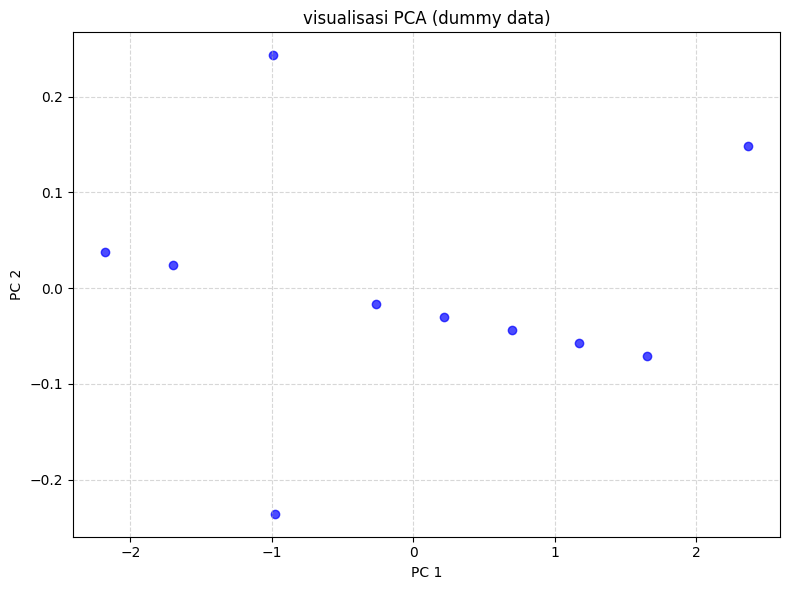

In [12]:
X_pca = X_std.dot(w)

logging.info(f"dimensi dataset sebelum pca: {X_std.shape}")
logging.info(f"dimensi dataset setelah pca: {X_pca.shape}")

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', alpha=0.7)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('visualisasi PCA (dummy data)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()